# Evaluación del modelo — Análisis en profundidad

En este notebook se realiza el análisis completo del mejor modelo seleccionado en `03_models.ipynb` (LightGBM). El objetivo es evaluar su comportamiento desde distintos ángulos relevantes para la aplicación clínica:

- **Curvas ROC y Precision-Recall** — capacidad discriminativa
- **Importancia de variables** — qué factores contribuyen más a la predicción
- **Análisis de umbral** — cómo afecta el umbral al trade-off precision/recall
- **Calibración y Brier Score** — fiabilidad de las probabilidades predichas
- **Decision Curve Analysis (DCA)** — utilidad clínica neta del modelo
- **Interpretabilidad SHAP** — explicación global e individual de las predicciones

## 1. Imports y carga del modelo

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import glob
import pandas as pd
import matplotlib.pyplot as plt

from src.models.train import load_data, split_data
from src.evaluation.evaluate import (
    plot_roc_curve,
    plot_precision_recall_curve,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_calibration_curve,
    brier_score,
    plot_dca,
    plot_shap_summary,
    get_classification_report,
    threshold_analysis
)

In [2]:
# Cargamos el mejor modelo guardado por el notebook 03
model_files = glob.glob("../models/*.pkl")
if not model_files:
    raise FileNotFoundError("No se encontró ningún modelo en models/. Ejecuta primero 03_models.ipynb")

model_path = model_files[0]
best_model = joblib.load(model_path)
best_model_name = os.path.basename(model_path).replace(".pkl", "").replace("_", " ").title()

print(f"Modelo cargado: {best_model_name}")
print(f"Ruta: {model_path}")

Modelo cargado: Lightgbm Tuned
Ruta: ../models\lightgbm_tuned.pkl


In [3]:
X, y = load_data()
X_train, X_test, y_train, y_test = split_data(X, y)

print(f"Test: {X_test.shape[0]:,} registros")

Dataset cargado: 315,982 registros, 54 variables. Tasa positivos: 0.342
Test: 63,197 registros


## 2. Curva ROC

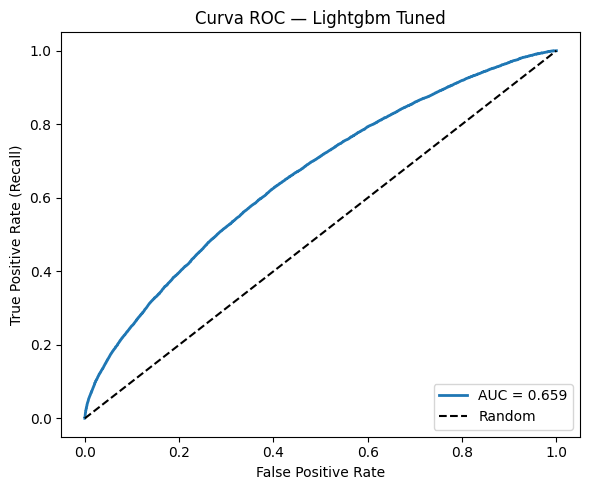

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_roc_curve(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/roc_best_model.png"
)
plt.tight_layout()
plt.show()

## 3. Curva Precision-Recall

La curva Precision-Recall complementa la ROC en escenarios con clases desbalanceadas. Muestra el trade-off entre detectar pacientes en riesgo (recall) y la fiabilidad de esas alertas (precision).

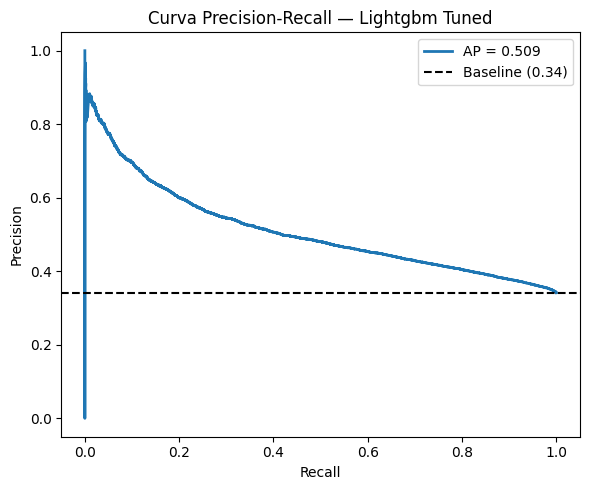

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_precision_recall_curve(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/pr_curve_best_model.png"
)
plt.tight_layout()
plt.show()

## 4. Matriz de confusión y reporte de clasificación

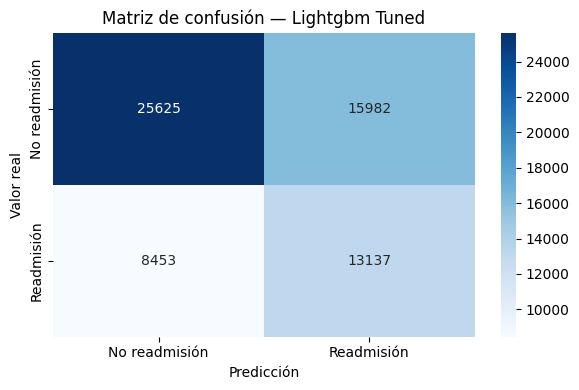

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_confusion_matrix(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/confusion_matrix_best_model.png"
)
plt.tight_layout()
plt.show()

In [7]:
get_classification_report(best_model, X_test, y_test)

,precision,recall,f1-score,support
No readmisión,0.752,0.616,0.677,41607.000
Readmisión,0.451,0.608,0.518,21590.000
accuracy,0.613,0.613,0.613,0.613
macro avg,0.602,0.612,0.598,63197.000
weighted avg,0.649,0.613,0.623,63197.000


## 5. Importancia de variables

El análisis de importancia de variables permite identificar qué factores clínicos y demográficos contribuyen más a la predicción de readmisión, aportando interpretabilidad al modelo.

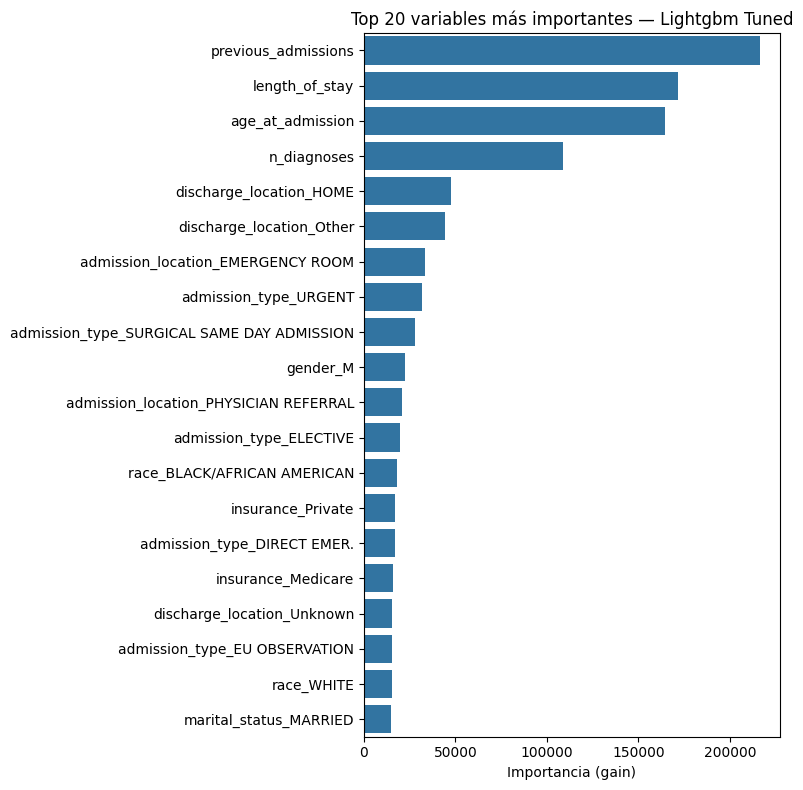

,feature,importance
2,previous_admissions,216607.306976
0,length_of_stay,171455.335953
3,age_at_admission,164706.821182
1,n_diagnoses,108985.720944
48,discharge_location_HOME,47846.600239
50,discharge_location_Other,44145.760551
39,admission_location_EMERGENCY ROOM,33402.363404
37,admission_type_URGENT,31724.849890
36,admission_type_SURGICAL SAME DAY ADMISSION,28021.271984
4,gender_M,22645.755131


In [8]:
importance_df = plot_feature_importance(
    best_model,
    feature_names=X.columns.tolist(),
    model_name=best_model_name,
    top_n=20,
    save_path="../results/feature_importance_best_model.png"
)
importance_df

## 6. Análisis de umbral de decisión

El umbral por defecto (0.5) no es siempre el óptimo en contexto clínico. Si el objetivo es detectar el máximo número de pacientes en riesgo (maximizar recall), puede ser preferible bajar el umbral, asumiendo más falsos positivos.

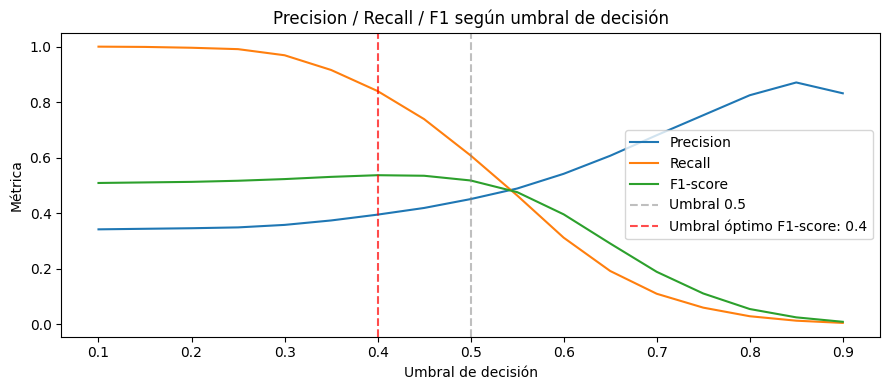


Umbral óptimo (F1-score): 0.4
Precision    0.395
Recall       0.840
F1-score     0.537


,Precision,Recall,F1-score
Threshold,,,
0.10,0.342,1.000,0.509
0.15,0.344,0.999,0.511
0.20,0.346,0.996,0.513
0.25,0.349,0.991,0.517
0.30,0.358,0.969,0.523
0.35,0.374,0.916,0.531
0.40,0.395,0.840,0.537
0.45,0.419,0.739,0.535
0.50,0.451,0.608,0.518


In [9]:
threshold_df = threshold_analysis(best_model, X_test, y_test)
threshold_df

## 7. Calibración y Brier Score

Un modelo bien calibrado es fundamental en contexto clínico: si predice un 70% de probabilidad de reingreso, eso debería corresponder aproximadamente a una tasa real del 70%. La curva de calibración (reliability diagram) muestra visualmente esta correspondencia. El Brier Score complementa la curva con un valor numérico del error cuadrático medio entre probabilidades predichas y etiquetas reales.

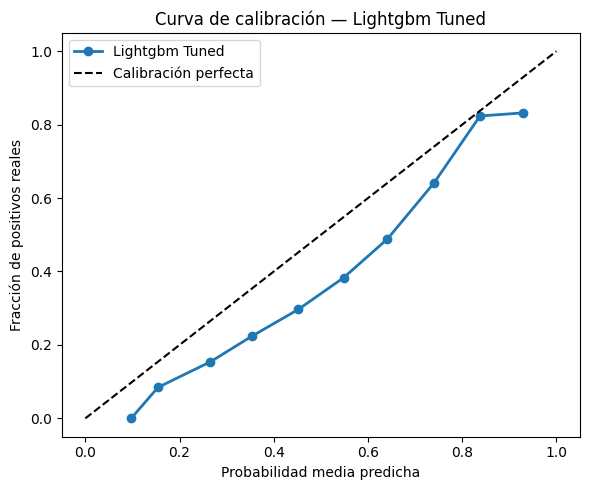


Brier Score:  0.2292
Baseline:     0.2249  (prediciendo siempre la prevalencia)
Mejora:       -0.0043


0.2292113639217282

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_calibration_curve(
    best_model, X_test, y_test,
    model_name=best_model_name,
    ax=ax,
    save_path="../results/calibration_best_model.png"
)
plt.tight_layout()
plt.show()

print()
brier_score(best_model, X_test, y_test)

## 8. Decision Curve Analysis (DCA)

La DCA evalúa la utilidad clínica neta del modelo comparándolo con las dos estrategias extremas: tratar a todos los pacientes (ignorar el modelo) o no tratar a ninguno. Si la curva del modelo queda por encima de ambas alternativas en un rango de umbrales, el modelo aporta valor real en ese rango de decisión clínica.

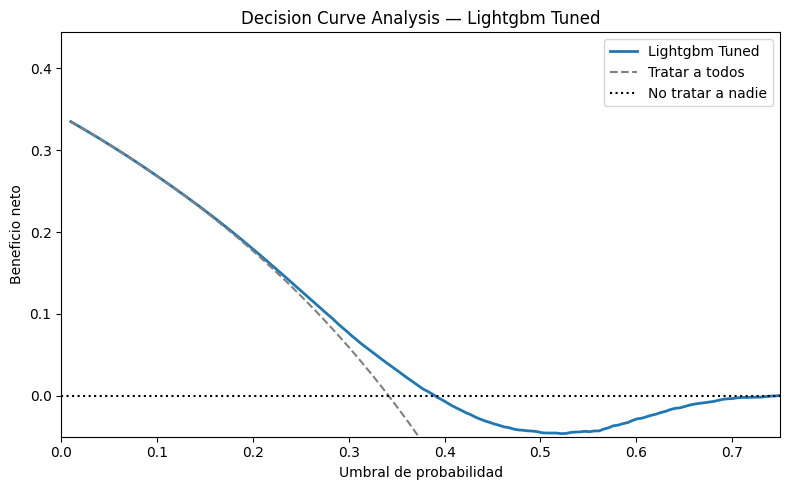

,threshold,net_benefit_model,net_benefit_all
0,0.010000,0.334980,0.334980
1,0.014966,0.331627,0.331627
2,0.019933,0.328240,0.328240
3,0.024899,0.324819,0.324819
4,0.029866,0.321362,0.321362
5,0.034832,0.317870,0.317870
6,0.039799,0.314342,0.314342
7,0.044765,0.310777,0.310777
8,0.049732,0.307175,0.307175
9,0.054698,0.303535,0.303535


In [11]:
dca_df = plot_dca(
    best_model, X_test, y_test,
    model_name=best_model_name,
    save_path="../results/dca_best_model.png"
)
dca_df.head(10)

## 9. Interpretabilidad SHAP

SHAP explica cuánto contribuye cada variable a cada predicción concreta. A diferencia de la importancia por ganancia (sección 5), tiene en cuenta cómo interactúan las variables entre sí. Los valores tienen signo: positivo empuja hacia predecir reingreso, negativo hacia no reingreso.

Se utiliza una muestra de 2.000 registros del test set para reducir el tiempo de cómputo sin perder representatividad.

In [ ]:
X_sample = X_test.sample(n=2000, random_state=42)

shap_df = plot_shap_summary(
    best_model, X_sample,
    model_name=best_model_name,
    max_display=20,
    save_path="../results/shap_summary_best_model.png"
)
shap_df

## 10. Conclusiones

Este análisis evalúa el modelo LightGBM tuneado desde los ángulos más relevantes para su posible uso clínico:

- La **curva ROC** y la **curva Precision-Recall** confirman la capacidad discriminativa del modelo (AUC ~0.66), coherente con la literatura de reingreso a 30 días con datos administrativos.
- La **importancia de variables** y los **valores SHAP** identifican los factores clínicos con mayor peso en la predicción, aportando interpretabilidad al modelo más allá de las métricas agregadas.
- El **análisis de umbral** permite ajustar el punto de corte según la tolerancia clínica al riesgo — bajando el umbral se detectan más reingresos a costa de más falsos positivos.
- La **calibración** y el **Brier Score** indican si las probabilidades predichas pueden usarse directamente como estimaciones de riesgo individual.
- La **DCA** muestra en qué rango de umbrales el modelo ofrece beneficio neto real frente a tratar a todos o no tratar a nadie.